# Capital Budgeting Analysis: Monte Carlo Simulation
**Scenario:** Specialty Coatings Production Line Expansion — Chemical Manufacturer  
**Tools:** Python | NumPy | Pandas | Matplotlib | SciPy  
**Purpose:** Evaluate capital project viability under uncertainty using DCF analysis and Monte Carlo simulation

## Model Assumptions & Limitations

This model is designed to illustrate capital budgeting methodology, not replace a full financial due diligence process. Users should be aware of the following simplifying assumptions:

- **Constant annual cash flows.** FCF is held flat across years 2–10. A more complete model would apply revenue growth rates and escalating maintenance costs (typically 2–3% annually for chemical equipment).
- **Year 1 ramp-up only.** The model applies a capacity ramp-up factor to Year 1 to reflect startup conditions, but assumes full-rate production from Year 2 onward. A phased ramp over 18–24 months would be more realistic for a greenfield line.
- **Stable feedstock costs.** Net revenue per ton is held constant. In practice, specialty chemicals margins are sensitive to feedstock price cycles, which can compress or expand contribution margins significantly year-to-year.
- **Input independence.** The Monte Carlo simulation draws each uncertain variable independently. In reality, inputs are correlated — a weak demand environment typically compresses both volume *and* pricing simultaneously.
- **No option value.** The model treats the investment as binary (accept/reject). It does not capture the value of managerial flexibility — the ability to expand, defer, or abandon the project as conditions evolve.
- **Simplified tax treatment.** A flat effective tax rate is applied uniformly. A complete model would account for depreciation tax shield timing, potential NOL carryforwards, and state/local tax obligations.

*These limitations are intentional and appropriate for the scope of this analysis. In a capital committee presentation, each would warrant a sensitivity test or scenario.*

##Import Libraries

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Project Assumptions
Net revenue per metric ton represents contribution margin after feedstock and variable costs.  
Fixed OpEx covers labor, utilities, maintenance, and SG&A allocated to the line.

In [55]:
# ─────────────────────────────────────────
# BASE CASE ASSUMPTIONS
# ─────────────────────────────────────────

project_name = "Specialty Coatings Production Line — Chemical Manufacturer"

# Capital outlay
initial_investment = 8_500_000    # $8.5M for new production line
salvage_value      =   750_000    # Estimated residual value at end of useful life
project_life       = 10           # Years

# Production assumptions
annual_volume_base = 3_200        # Metric tons per year (base case)
net_rev_per_ton    = 950          # Net contribution margin per ton (after feedstock/variable costs)

# Cost assumptions
annual_opex        = 1_100_000    # Fixed operating costs (labor, utilities, maintenance)
depreciation       = (initial_investment - salvage_value) / project_life

# Finance
discount_rate      = 0.0725       # WACC (7.25% — source: Damadoran Online (NYU Stern) (https://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/wacc.htm)
tax_rate           = 0.21         # Effective corporate tax rate

print(f"Project: {project_name}")
print(f"Initial Investment:    ${initial_investment:,.0f}")
print(f"Annual Depreciation:   ${depreciation:,.0f}")
print(f"Annual Revenue (base): ${annual_volume_base * net_rev_per_ton:,.0f}")

Project: Specialty Coatings Production Line — Chemical Manufacturer
Initial Investment:    $8,500,000
Annual Depreciation:   $775,000
Annual Revenue (base): $3,040,000


*WACC sourced from Damodaran (NYU Stern) industry dataset — Specialty Chemicals;
based on 59 firms. Cost of Equity: 8.28%, Cost of Debt: 5.07%.
https://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/wacc.htm

## Deterministic DCF Model
Base case analysis using fixed assumptions. This establishes the single-scenario answer before we introduce uncertainty in the Monte Carlo.

In [56]:
def calculate_fcf(volume, net_rev_per_unit, opex, depreciation, tax_rate):
    """Calculate annual unlevered free cash flow."""
    revenue = volume * net_rev_per_unit
    ebitda  = revenue - opex
    ebit    = ebitda - depreciation
    nopat   = ebit * (1 - tax_rate)   # Net operating profit after tax
    fcf     = nopat + depreciation    # Add back non-cash depreciation charge
    return fcf


def calculate_npv(initial_investment, annual_fcf, salvage_value,
                  project_life, discount_rate, ramp_up=0.65):
    """
    Calculate NPV across the full project life.
    ramp_up: fraction of full-rate FCF achieved in Year 1 (default 65%).
    Reflects typical startup conditions for a new chemical production line.
    """
    cash_flows = [-initial_investment]
    for year in range(1, project_life + 1):
        year_fcf = annual_fcf * (ramp_up if year == 1 else 1.0)
        if year == project_life:
            year_fcf += salvage_value
        cash_flows.append(year_fcf)


    npv_value = sum(cf / (1 + discount_rate)**t
              for t, cf in enumerate(cash_flows))
    return npv_value, cash_flows

def calculate_payback(cash_flows):
    """
    Calculate the payback period.
    Assumes the first cash flow is the initial investment (negative).
    """
    cumulative_cash_flow = 0
    payback_period = 0
    for i, cf in enumerate(cash_flows):
        cumulative_cash_flow += cf
        if cumulative_cash_flow > 0 and payback_period == 0:
            # Linear interpolation for fractional year
            payback_period = i - 1 + (abs(cumulative_cash_flow - cf) / cf)
    if cumulative_cash_flow <= 0 and payback_period == 0: # If it never pays back
        return "Never"
    return round(payback_period)


# ─── Re-run Base Case with Ramp-Up ───
ramp_up_factor = 0.65   # 65% of full capacity in Year 1

# Calculate base_fcf before using it
base_fcf = calculate_fcf(
    annual_volume_base, net_rev_per_ton, annual_opex,
    depreciation, tax_rate
)

npv, cf_schedule = calculate_npv(
    initial_investment, base_fcf, salvage_value,
    project_life, discount_rate, ramp_up=ramp_up_factor
)

base_case_npv = npv

payback = calculate_payback(cf_schedule)

print("=" * 50)
print("BASE CASE RESULTS (with Year 1 ramp-up)")
print("=" * 50)
print(f"Year 1 FCF (65% rate):  ${base_fcf * ramp_up_factor:>12,.0f}")
print(f"Full-Rate Annual FCF:   ${base_fcf:>12,.0f}")
print(f"Net Present Value:      ${npv:>12,.0f}")
print(f"Payback Period:          {payback} years")
print(f"Decision:               {'✓ ACCEPT' if npv > 0 else '✗ REJECT'}")

BASE CASE RESULTS (with Year 1 ramp-up)
Year 1 FCF (65% rate):  $   1,101,978
Full-Rate Annual FCF:   $   1,695,350
Net Present Value:      $   3,090,239
Payback Period:          5 years
Decision:               ✓ ACCEPT


## Scenario Analysis
Three discrete scenarios test how the project performs across a range of market conditions. WACC values are anchored to the Damodaran Specialty Chemicals base rate (7.25%) with stress adjustments for bear and bull cases. The Year 1 ramp-up factor is held constant across all scenarios; ramp-up reflects a physical startup constraint, not a market variable.


In [57]:
scenarios = {
    "Bear Case": {
        "volume":              2_600,      # 81% of base — modest demand underperformance
        "net_rev_per_unit":    895,        # 6% margin compression from feedstock pressure
        "opex":                1_250_000,  # 14% above base — some cost creep, not severe
        "wacc":                0.0875,     # +150 bps above Damodaran base (credit stress)
    },
    "Base Case": {
        "volume":              3_200,      # Full design capacity from Year 2
        "net_rev_per_unit":    950,        # Damodaran-calibrated contribution margin
        "opex":                1_100_000,  # Standard fixed operating costs
        "wacc":                0.0725,     # Damodaran Specialty Chemicals WACC
    },
    "Bull Case": {
        "volume":              4_000,      # 125% of base — strong demand, rapid adoption
        "net_rev_per_unit":    1_040,      # Expanded margins from favorable pricing
        "opex":                1_000_000,  # Efficiency gains at higher utilization
        "wacc":                0.065,      # -75 bps (favorable credit, lower risk premium)
    },
}
results = []
for name, s in scenarios.items():
    fcf = calculate_fcf(
        s["volume"], s["net_rev_per_unit"], s["opex"],
        depreciation, tax_rate
    )
    npv, cfs = calculate_npv(
        initial_investment, fcf, salvage_value,
        project_life, s["wacc"], ramp_up=ramp_up_factor
    )
    pb = calculate_payback(cfs)
    results.append({
        "Scenario":      name,
        "Volume (MT)":   f"{s['volume']:,}",
        "Rev/Ton":       f"${s['net_rev_per_unit']:,}",
        "Annual FCF":    f"${fcf:,.0f}",
        "NPV":           f"${npv:,.0f}",
        "Payback (yrs)": pb,
        "Decision":      "Accept" if npv > 0 else "Reject",
    })

df_scenarios = pd.DataFrame(results)
print(df_scenarios.to_string(index=False))

 Scenario Volume (MT) Rev/Ton Annual FCF         NPV  Payback (yrs) Decision
Bear Case       2,600    $895 $1,013,580 $-1,925,038              9   Reject
Base Case       3,200    $950 $1,695,350  $3,090,239              5   Accept
Bull Case       4,000  $1,040 $2,659,150 $10,141,823              4   Accept


## Sensitivity Analysis — Tornado Chart
Tests the impact of each input variable individually at ±20%, holding all others at base case values. Bars are sorted by magnitude of NPV impact, largest at top. This identifies which assumptions most warrant scrutiny in due diligence.

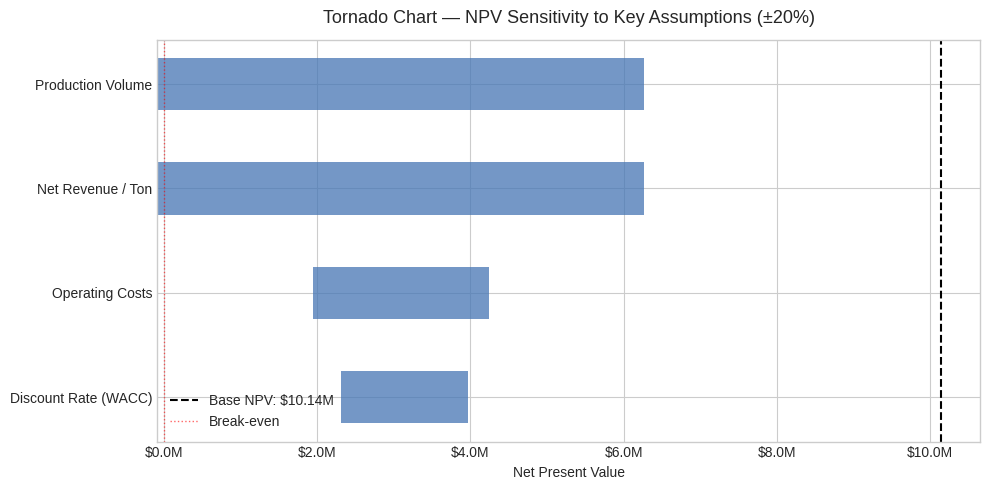

In [58]:
base_npv = npv  # Base case NPV from Step 3

sensitivity_vars = {
    "Production Volume":     ("volume",          annual_volume_base, 0.20),
    "Net Revenue / Ton":     ("net_rev_per_unit", net_rev_per_ton,   0.20),
    "Operating Costs":       ("opex",             annual_opex,       0.20),
    "Discount Rate (WACC)":  ("wacc",             discount_rate,     0.20),
}

tornado_data = []
for label, (var, base_val, pct) in sensitivity_vars.items():
    sens_results = {}
    for direction, multiplier in [("Low", 1 - pct), ("High", 1 + pct)]:
        s = {
            "volume":          annual_volume_base,
            "net_rev_per_unit": net_rev_per_ton,
            "opex":            annual_opex,
            "wacc":            discount_rate,
        }
        s[var] = base_val * multiplier
        fcf = calculate_fcf(
            s["volume"], s["net_rev_per_unit"], s["opex"],
            depreciation, tax_rate
        )
        n, _ = calculate_npv(
            initial_investment, fcf, salvage_value,
            project_life, s["wacc"], ramp_up=ramp_up_factor
        )
        sens_results[direction] = n

    tornado_data.append({
        "Variable": label,
        "Low":      sens_results["Low"],
        "High":     sens_results["High"],
        "Range":    abs(sens_results["High"] - sens_results["Low"]),
    })

df_tornado = pd.DataFrame(tornado_data).sort_values("Range")

# ─── Plot ───
fig, ax = plt.subplots(figsize=(10, 5))

for _, row in df_tornado.iterrows():
    low, high = sorted([row["Low"], row["High"]])
    ax.barh(row["Variable"], high - low, left=low,
            color="#4575b4", alpha=0.75, height=0.5)

ax.axvline(base_npv, color="black", linewidth=1.5,
           linestyle="--", label=f"Base NPV: ${base_npv/1e6:.2f}M")
ax.axvline(0, color="red", linewidth=1, linestyle=":", alpha=0.6, label="Break-even")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M"))
ax.set_title("Tornado Chart — NPV Sensitivity to Key Assumptions (±20%)",
             fontsize=13, pad=12)
ax.set_xlabel("Net Present Value")
ax.legend()
plt.tight_layout()
plt.savefig("tornado_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Monte Carlo Simulation
The tornado chart identified Production Volume and Net Revenue per Ton as the two dominant NPV drivers — nearly equal in sensitivity. This guides the distribution widths below: volume and revenue carry wider standard deviations to reflect their greater uncertainty.

Note: inputs are sampled independently. In practice, volume and net revenue per ton are likely positively correlated — weak demand environments tend to compress both simultaneously. This independence assumption causes the model to modestly understate downside risk in adverse scenarios.

In [59]:
np.random.seed(42)
N_SIMULATIONS = 10_000

# Distributions reflect sensitivity ranking from tornado chart
# Volume and rev/ton carry wider uncertainty; opex is more predictable
sim_volume       = np.random.normal(3_200,   480,     N_SIMULATIONS).clip(1_500,   5_000)
sim_rev_per_ton  = np.random.normal(950,     95,      N_SIMULATIONS).clip(650,     1_250)
sim_opex         = np.random.normal(1_100_000, 130_000, N_SIMULATIONS).clip(750_000, 1_600_000)
sim_wacc         = np.random.normal(0.0725,  0.0125,  N_SIMULATIONS).clip(0.04,    0.14)

# Run simulations
sim_npvs = []
for i in range(N_SIMULATIONS):
    fcf = calculate_fcf(
        sim_volume[i], sim_rev_per_ton[i], sim_opex[i],
        depreciation, tax_rate
    )
    n, _ = calculate_npv(
        initial_investment, fcf, salvage_value,
        project_life, sim_wacc[i], ramp_up=ramp_up_factor
    )
    sim_npvs.append(n)

sim_npvs = np.array(sim_npvs)

# Summary statistics
pct_positive = (sim_npvs > 0).mean() * 100
p10, p50, p90 = np.percentile(sim_npvs, [10, 50, 90])

print("=" * 50)
print("MONTE CARLO RESULTS  (N = 10,000)")
print("=" * 50)
print(f"Probability NPV > 0:   {pct_positive:.1f}%")
print(f"P10 (pessimistic):     ${p10:,.0f}")
print(f"P50 (median):          ${p50:,.0f}")
print(f"P90 (optimistic):      ${p90:,.0f}")
print(f"Mean NPV:              ${sim_npvs.mean():,.0f}")
print(f"Std Deviation:         ${sim_npvs.std():,.0f}")

MONTE CARLO RESULTS  (N = 10,000)
Probability NPV > 0:   85.6%
P10 (pessimistic):     $-654,599
P50 (median):          $2,978,454
P90 (optimistic):      $7,151,894
Mean NPV:              $3,149,446
Std Deviation:         $3,028,653


## Monte Carlo Visualization
# Two charts: a histogram showing the full NPV distribution with key percentiles marked, and a cumulative probability curve (S-curve) showing the probability of achieving any given NPV level. The shaded red region on the S-curve represents the portion of simulations with negative NPV.

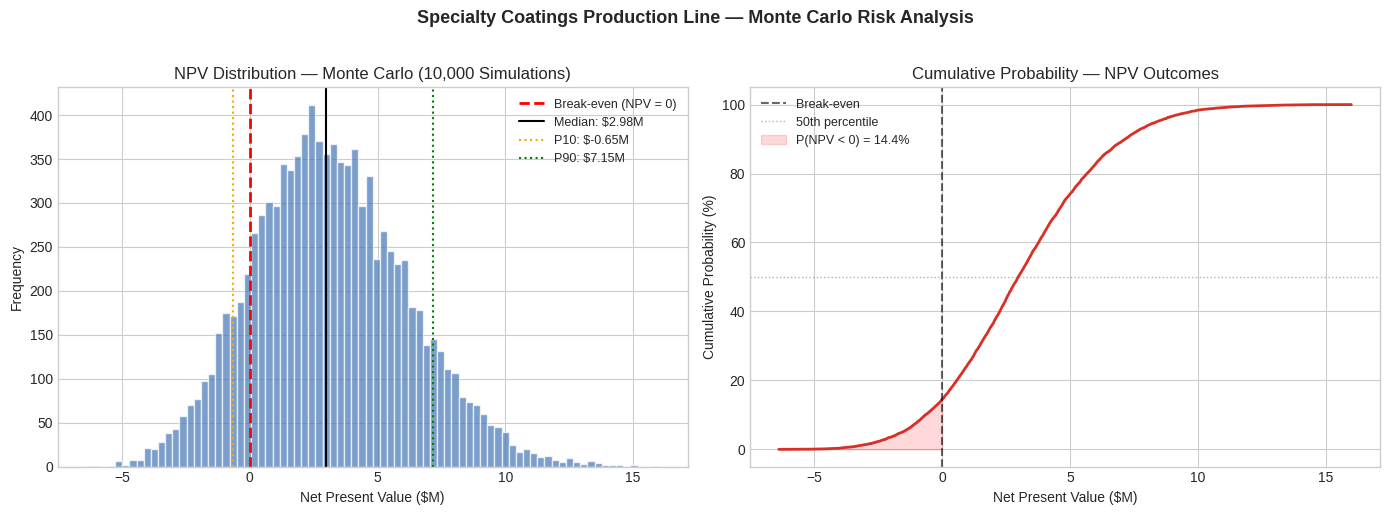

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Left: NPV Distribution Histogram ───
ax = axes[0]
ax.hist(sim_npvs / 1e6, bins=80, color="#4575b4", alpha=0.7, edgecolor="white")
ax.axvline(0,        color="red",    linewidth=2,   linestyle="--", label="Break-even (NPV = 0)")
ax.axvline(p50/1e6,  color="black",  linewidth=1.5, linestyle="-",  label=f"Median: ${p50/1e6:.2f}M")
ax.axvline(p10/1e6,  color="orange", linewidth=1.5, linestyle=":",  label=f"P10: ${p10/1e6:.2f}M")
ax.axvline(p90/1e6,  color="green",  linewidth=1.5, linestyle=":",  label=f"P90: ${p90/1e6:.2f}M")
ax.set_title("NPV Distribution — Monte Carlo (10,000 Simulations)", fontsize=12)
ax.set_xlabel("Net Present Value ($M)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)

# ─── Right: Cumulative Probability S-Curve ───
ax2 = axes[1]
sorted_npvs = np.sort(sim_npvs)
cumulative  = np.arange(1, len(sorted_npvs) + 1) / len(sorted_npvs)
ax2.plot(sorted_npvs / 1e6, cumulative * 100, color="#d73027", linewidth=2)
ax2.axvline(0,  color="black", linewidth=1.5, linestyle="--", alpha=0.6, label="Break-even")
ax2.axhline(50, color="gray",  linewidth=1,   linestyle=":",  alpha=0.6, label="50th percentile")
ax2.fill_betweenx(
    cumulative * 100, sorted_npvs / 1e6, 0,
    where=(sorted_npvs < 0),
    alpha=0.15, color="red",
    label=f"P(NPV < 0) = {100 - pct_positive:.1f}%"
)
ax2.set_title("Cumulative Probability — NPV Outcomes", fontsize=12)
ax2.set_xlabel("Net Present Value ($M)")
ax2.set_ylabel("Cumulative Probability (%)")
ax2.legend(fontsize=9)

plt.suptitle(
    "Specialty Coatings Production Line — Monte Carlo Risk Analysis",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("monte_carlo_npv.png", dpi=150, bbox_inches="tight")
plt.show()

## Executive Summary
Consolidated output suitable for a capital committee presentation. Combines the deterministic base case result with probabilistic findings from the Monte Carlo to support a final recommendation.

In [61]:
decision_threshold = 0.70  # Recommend approval if P(NPV > 0) >= 70%

print("=" * 58)
print("  CAPITAL BUDGETING ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 58)
print(f"\n  Project:         {project_name}")
print(f"  Initial Outlay:  ${initial_investment:,.0f}")
print(f"  Useful Life:     {project_life} years")
print(f"  Discount Rate:   {discount_rate:.2%}  (Damodaran Specialty Chemicals WACC)")
print(f"  Year 1 Ramp-Up:  {ramp_up_factor:.0%} of full-rate capacity")
print()
print("-" * 58)
print("  SCENARIO ANALYSIS")
print(f"    {'Scenario':<12} {'NPV':>14}  {'Decision'}")
print(f"    {'-'*12} {'-'*14}  {'-'*8}")
for row in results:
    print(f"    {row['Scenario']:<12} {row['NPV']:>14}  {row['Decision']}")
print()
print("-" * 58)
print("  PROBABILISTIC ANALYSIS  (Monte Carlo, N=10,000)")
print(f"    P(NPV > 0):        {pct_positive:.1f}%")
print(f"    P10 (downside):    ${p10:,.0f}")
print(f"    P50 (median):      ${p50:,.0f}")
print(f"    P90 (upside):      ${p90:,.0f}")
print(f"    Std Deviation:     ${sim_npvs.std():,.0f}")
print()
print("-" * 58)
rec = "RECOMMEND APPROVAL" if pct_positive >= decision_threshold * 100 else "RECOMMEND FURTHER REVIEW"
print(f"\n  RECOMMENDATION:    {rec}")
print(f"\n  Rationale: Base case NPV of ${base_case_npv:,.0f} at a {discount_rate:.2%} WACC")
print(f"  exceeds the investment threshold. Monte Carlo analysis")
print(f"  confirms {pct_positive:.1f}% probability of value creation, with")
print(f"  bounded downside of ${abs(p10):,.0f} at the 10th percentile.")
print("=" * 58)

  CAPITAL BUDGETING ANALYSIS — EXECUTIVE SUMMARY

  Project:         Specialty Coatings Production Line — Chemical Manufacturer
  Initial Outlay:  $8,500,000
  Useful Life:     10 years
  Discount Rate:   7.25%  (Damodaran Specialty Chemicals WACC)
  Year 1 Ramp-Up:  65% of full-rate capacity

----------------------------------------------------------
  SCENARIO ANALYSIS
    Scenario                NPV  Decision
    ------------ --------------  --------
    Bear Case       $-1,925,038  Reject
    Base Case        $3,090,239  Accept
    Bull Case       $10,141,823  Accept

----------------------------------------------------------
  PROBABILISTIC ANALYSIS  (Monte Carlo, N=10,000)
    P(NPV > 0):        85.6%
    P10 (downside):    $-654,599
    P50 (median):      $2,978,454
    P90 (upside):      $7,151,894
    Std Deviation:     $3,028,653

----------------------------------------------------------

  RECOMMENDATION:    RECOMMEND APPROVAL

  Rationale: Base case NPV of $3,090,239 at a 